# Notebook 06 — Evaluation

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 6:** Evaluate pipeline outputs against ground truth COCO annotations

**Input:**
- Ground truth: `data/labels/_annotations_coco.json`
- Detected lines: `outputs/04_hough/lines.json` (from NB04)
- Metric measurements: `outputs/05_metric/measurements.json` (from NB05)
- Calibration: `outputs/02_rectified/calibration.json` (from NB02)

**Output:**
- Full report: `outputs/06_evaluation/report.json`
- Summary plot: `outputs/06_evaluation/summary.png`

**This notebook does NOT reprocess any image.** It only reads the outputs
saved by previous notebooks and compares them against the ground truth.

**Metrics:**
- IoU, Precision, Recall, F1 — detection quality
- MAE, RMSE — metric accuracy of edge x positions in mm
- Processing speed — measured by re-timing the full pipeline on each image

## 1. Imports and configuration

In [30]:
!pip install opencv-python numpy matplotlib pycocotools

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
import time
from pathlib import Path
from pycocotools import mask as coco_mask

In [32]:
# ── Paths ──────────────────────────────────────────────────────────────────
ANNOTATIONS_PATH = Path("data/labels/_annotations_coco.json")
CALIB_PATH       = Path("outputs/02_rectified/calibration.json")
LINES_PATH       = Path("outputs/04_hough/lines.json")
METRIC_PATH      = Path("outputs/05_metric/measurements.json")
PREPROCESSED_DIR = Path("outputs/01_preprocessed")  # for speed measurement
OUTPUT_DIR       = Path("outputs/06_evaluation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Evaluation parameters ──────────────────────────────────────────────────
EDGE_LINE_WIDTH = 10   # px tolerance band when converting lines to masks
IOU_THRESHOLD   = 0.1  # min IoU to count a detection as TP

# Load all outputs from previous notebooks
with open(ANNOTATIONS_PATH) as f:
    coco_data = json.load(f)
with open(CALIB_PATH) as f:
    calibration_data = json.load(f)
with open(LINES_PATH) as f:
    hough_results = json.load(f)
with open(METRIC_PATH) as f:
    metric_results = json.load(f)

print(f"GT images         : {len(coco_data['images'])}")
print(f"GT annotations    : {len(coco_data['annotations'])}")
print(f"Calibrated images : {len(calibration_data)}")
print(f"Images with lines : {len(hough_results)}")
print(f"Images with metric: {len(metric_results)}")

GT images         : 22
GT annotations    : 98
Calibrated images : 20
Images with lines : 20
Images with metric: 18


## 2. Ground truth parsing

In [33]:
img_info       = {img['file_name']: img for img in coco_data['images']}
img_id_to_name = {img['id']: img['file_name'] for img in coco_data['images']}
cat_name_to_id = {c['name']: c['id'] for c in coco_data['categories']}
CUT_EDGE_CAT   = cat_name_to_id.get('cut_edge', 1)

print(f"Categories      : {cat_name_to_id}")
print(f"Cut edge cat id : {CUT_EDGE_CAT}")

gt_by_image = {}
for ann in coco_data['annotations']:
    if ann['category_id'] != CUT_EDGE_CAT:
        continue
    name = img_id_to_name[ann['image_id']]
    gt_by_image.setdefault(name, []).append(ann)

print(f"Images with GT  : {len(gt_by_image)}")

Categories      : {'Michelin-Proyect-Challenge-Seg': 0, 'cut_edge': 1, 'qr_code': 2}
Cut edge cat id : 1
Images with GT  : 17


## 3. Mask utilities

In [34]:
def gt_to_mask(ann: dict, img_h: int, img_w: int) -> np.ndarray:
    """Convert a COCO annotation (RLE or polygon) to a binary mask."""
    seg = ann['segmentation']
    if isinstance(seg, dict):
        rle = {
            'size'  : seg['size'],
            'counts': seg['counts'].encode('utf-8')
                      if isinstance(seg['counts'], str) else seg['counts']
        }
        m = coco_mask.decode(rle)
    else:
        rle = coco_mask.frPyObjects(seg, img_h, img_w)
        m   = coco_mask.decode(rle)
        if m.ndim == 3:
            m = m[:, :, 0]
    return (m > 0).astype(np.uint8)


def line_to_mask(x1, y1, x2, y2, img_h, img_w,
                 width=EDGE_LINE_WIDTH) -> np.ndarray:
    """Convert a predicted line segment to a binary mask with tolerance band."""
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.line(mask, (int(x1), int(y1)), (int(x2), int(y2)), 1, width)
    return mask


def compute_iou(a: np.ndarray, b: np.ndarray) -> float:
    intersection = np.logical_and(a, b).sum()
    union        = np.logical_or(a, b).sum()
    return float(intersection / union) if union > 0 else 0.0

## 4. Detection evaluation (IoU, Precision, Recall, F1)

In [35]:
def evaluate_detection(image_name: str) -> dict | None:
    if image_name not in gt_by_image or image_name not in hough_results:
        return None

    info   = img_info[image_name]
    img_h  = info['height']
    img_w  = info['width']

    gt_masks   = [gt_to_mask(ann, img_h, img_w) for ann in gt_by_image[image_name]]
    pred_edges = hough_results[image_name]['cut_edges_px']
    pred_masks = [line_to_mask(e[0], e[1], e[2], e[3], img_h, img_w)
                  for e in pred_edges]

    matched_gt = set()
    TP         = 0
    iou_scores = []

    for pred_mask in pred_masks:
        best_iou, best_gt = 0.0, -1
        for j, gt_mask in enumerate(gt_masks):
            if j in matched_gt:
                continue
            iou = compute_iou(pred_mask, gt_mask)
            if iou > best_iou:
                best_iou, best_gt = iou, j
        if best_iou >= IOU_THRESHOLD and best_gt >= 0:
            TP += 1
            matched_gt.add(best_gt)
            iou_scores.append(best_iou)

    FP        = len(pred_masks) - TP
    FN        = len(gt_masks)   - TP
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    return {
        'TP'       : TP,
        'FP'       : FP,
        'FN'       : FN,
        'precision': round(precision, 4),
        'recall'   : round(recall,    4),
        'f1'       : round(f1,        4),
        'mean_iou' : round(np.mean(iou_scores) if iou_scores else 0.0, 4),
        'n_gt'     : len(gt_masks),
        'n_pred'   : len(pred_masks)
    }

## 5. Metric evaluation (MAE, RMSE)

In [36]:
def evaluate_metric(image_name: str) -> dict | None:
    if image_name not in gt_by_image or image_name not in metric_results:
        return None

    calib = calibration_data[image_name]
    scale = float(calib['px_per_mm'])
    tl_x  = float(calib['corners_px'][0][0])

    # GT edge x positions in mm (centre of GT bbox)
    gt_x_mm = sorted([
        (float(ann['bbox'][0]) + float(ann['bbox'][2]) / 2 - tl_x) / scale
        for ann in gt_by_image[image_name]
    ])

    # Predicted edge x positions in mm (from NB05)
    pred_x_mm = sorted([
        m['edge_x_mm'] for m in metric_results[image_name]['measurements']
    ])

    n_match = min(len(gt_x_mm), len(pred_x_mm))
    if n_match == 0:
        return None

    errors = [abs(pred_x_mm[i] - gt_x_mm[i]) for i in range(n_match)]
    return {
        'gt_x_mm'  : [round(x, 2) for x in gt_x_mm],
        'pred_x_mm': [round(x, 2) for x in pred_x_mm],
        'errors_mm': [round(e, 2) for e in errors],
        'mae_mm'   : round(float(np.mean(errors)), 2),
        'rmse_mm'  : round(float(np.sqrt(np.mean([e**2 for e in errors]))), 2),
        'n_matched': n_match
    }

## 6. Speed measurement

Re-runs the full pipeline (NB01→NB04) on each image to measure processing time.
Uses the same parameters as the individual notebooks.

In [37]:
def measure_speed(image_name: str, n_runs: int = 5) -> float:
    img_path = Path("data/images") / image_name
    
    # Comprobar que la imagen existe
    if not img_path.exists():
        print(f"  [WARN] Image not found for speed measurement: {img_path}")
        return 0.0
    
    times = []
    for _ in range(n_runs):
        # ... resto del código igual
        t0 = time.perf_counter()

        # NB01: gris + CLAHE + blur
        img      = cv2.imread(str(img_path))
        gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        eq       = clahe.apply(gray)
        blurred  = cv2.GaussianBlur(eq, (5,5), 0)

        # NB03: segmentación + Canny
        _, mask  = cv2.threshold(blurred, 0, 255,
                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        mask     = cv2.bitwise_not(mask)
        kernel   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
        mask     = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        edges    = cv2.Canny(mask, 50, 150)

        # NB04: Hough
        cv2.HoughLinesP(edges, 1, np.pi/180,
                        threshold=50, minLineLength=80, maxLineGap=30)

        times.append(time.perf_counter() - t0)

    return float(np.mean(times))

## 7. Run full evaluation

In [38]:
eval_results = {}

for image_name in calibration_data:
    det   = evaluate_detection(image_name)
    met   = evaluate_metric(image_name)
    speed = measure_speed(image_name)
    if speed == 0.0:
        continue

    if det is None:
        continue

    eval_results[image_name] = {
        'detection': det,
        'metric'   : met,
        'speed_s'  : round(speed, 4)
    }

    mae_str = f"{met['mae_mm']:7.2f}" if met else '    N/A'
    print(f"  {image_name:30s}  "
          f"P={det['precision']:.2f}  R={det['recall']:.2f}  "
          f"F1={det['f1']:.2f}  IoU={det['mean_iou']:.2f}  "
          f"MAE={mae_str} mm  t={speed:.3f}s")

with open(OUTPUT_DIR / "report.json", "w") as f:
    json.dump(eval_results, f, indent=2)
print(f"\nReport saved to {OUTPUT_DIR / 'report.json'}")

  Multimedia_31.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE= 291.25 mm  t=0.027s
  Multimedia_32.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE= 277.25 mm  t=0.024s
  Multimedia_33.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE= 265.25 mm  t=0.024s
  Multimedia_34.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE= 285.00 mm  t=0.023s
  Multimedia_35.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE= 412.25 mm  t=0.023s
  Multimedia_36.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE= 426.25 mm  t=0.024s
  Multimedia_37.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE= 399.50 mm  t=0.025s
  Multimedia_39.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE= 129.00 mm  t=0.022s
  Multimedia_40.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE= 132.50 mm  t=0.021s
  Multimedia_41.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE= 173.50 mm  t=0.027s
  Multimedia_42.jpg               P=0.00  R=0.00  F1=0.00  I

## 8. Aggregate metrics

In [39]:
precisions = [r['detection']['precision'] for r in eval_results.values()]
recalls    = [r['detection']['recall']    for r in eval_results.values()]
f1s        = [r['detection']['f1']        for r in eval_results.values()]
ious       = [r['detection']['mean_iou']  for r in eval_results.values()]
maes       = [r['metric']['mae_mm']  for r in eval_results.values() if r['metric']]
rmses      = [r['metric']['rmse_mm'] for r in eval_results.values() if r['metric']]
speeds     = [r['speed_s'] for r in eval_results.values()]

print("=" * 55)
print("AGGREGATE EVALUATION RESULTS")
print("=" * 55)
print(f"Images evaluated  : {len(eval_results)}")
print()
print("Detection metrics:")
print(f"  Mean Precision  : {np.mean(precisions):.4f}")
print(f"  Mean Recall     : {np.mean(recalls):.4f}")
print(f"  Mean F1         : {np.mean(f1s):.4f}")
print(f"  Mean IoU        : {np.mean(ious):.4f}")
print()
print("Metric accuracy:")
print(f"  Mean MAE  (mm)  : {np.mean(maes):.2f}"  if maes  else "  Mean MAE  (mm)  : N/A")
print(f"  Mean RMSE (mm)  : {np.mean(rmses):.2f}" if rmses else "  Mean RMSE (mm)  : N/A")
print()
print("Speed:")
print(f"  Mean time/image : {np.mean(speeds):.4f} s")
print(f"  Images/second   : {1/np.mean(speeds):.2f}")
print(f"  Images/minute   : {60/np.mean(speeds):.1f}")
print("=" * 55)

AGGREGATE EVALUATION RESULTS
Images evaluated  : 15

Detection metrics:
  Mean Precision  : 0.0000
  Mean Recall     : 0.0000
  Mean F1         : 0.0000
  Mean IoU        : 0.0000

Metric accuracy:
  Mean MAE  (mm)  : 312.65
  Mean RMSE (mm)  : 334.85

Speed:
  Mean time/image : 0.0242 s
  Images/second   : 41.35
  Images/minute   : 2480.7


## 9. Summary plot

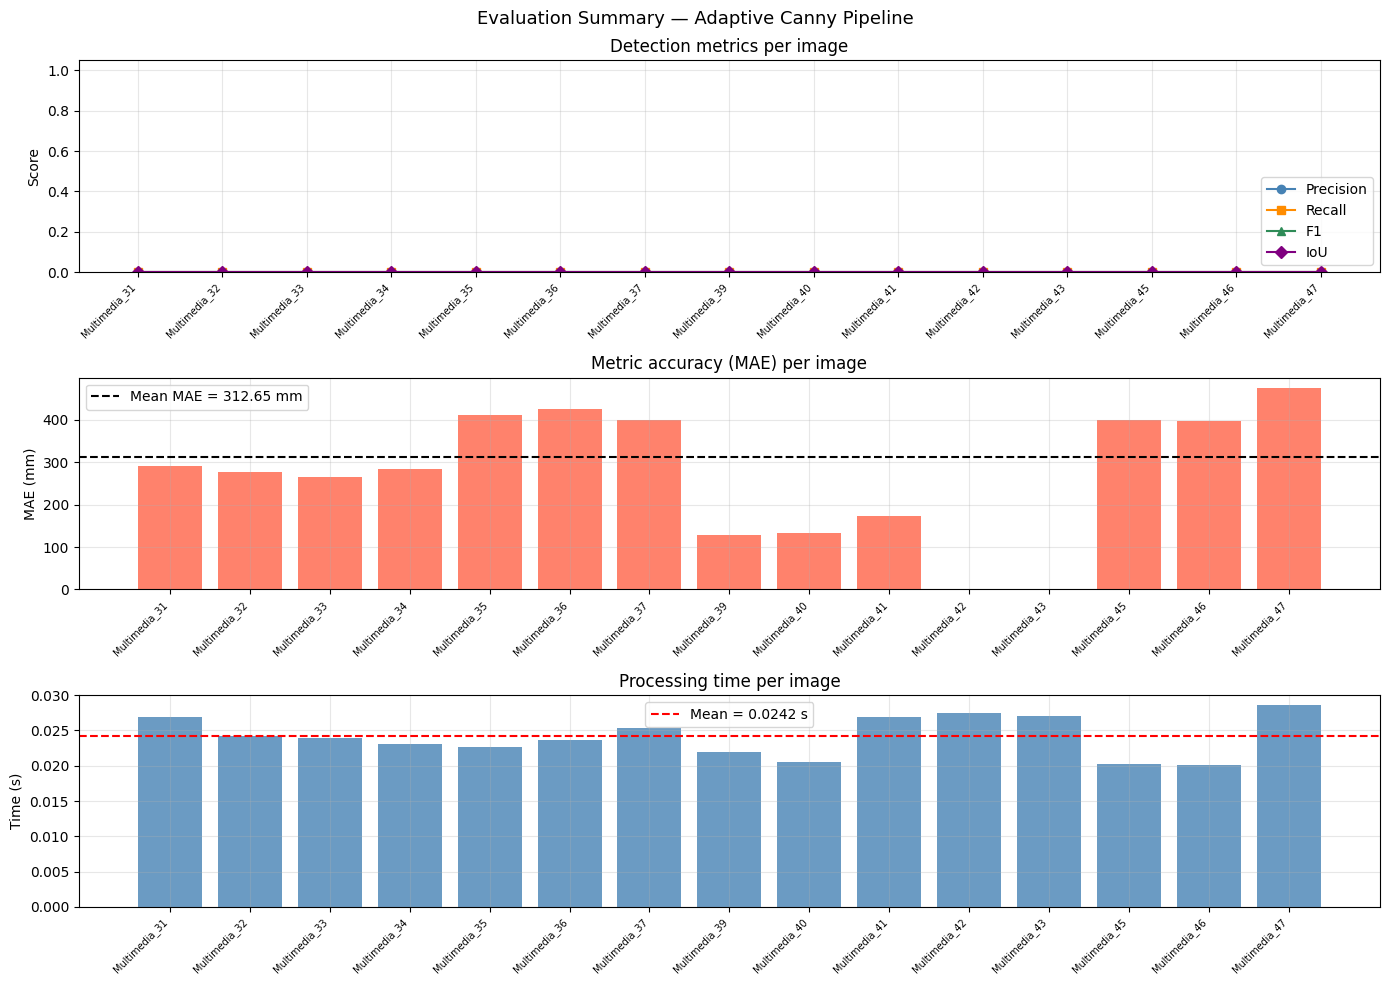

In [40]:
names   = list(eval_results.keys())
x       = range(len(names))
xlabels = [n.replace('.jpg', '') for n in names]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Evaluation Summary — Adaptive Canny Pipeline', fontsize=13)

# Detection metrics
axes[0].plot(x, precisions, 'o-', color='steelblue',  label='Precision')
axes[0].plot(x, recalls,    's-', color='darkorange',  label='Recall')
axes[0].plot(x, f1s,        '^-', color='seagreen',    label='F1')
axes[0].plot(x, ious,       'D-', color='purple',      label='IoU')
axes[0].set_ylim(0, 1.05)
axes[0].set_xticks(x); axes[0].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Score'); axes[0].set_title('Detection metrics per image')
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

# MAE
mae_vals = [eval_results[n]['metric']['mae_mm']
            if eval_results[n]['metric'] else np.nan for n in names]
axes[1].bar(x, mae_vals, color='tomato', alpha=0.8)
axes[1].axhline(np.nanmean(mae_vals), color='black', linestyle='--',
                label=f'Mean MAE = {np.nanmean(mae_vals):.2f} mm')
axes[1].set_xticks(x); axes[1].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('MAE (mm)'); axes[1].set_title('Metric accuracy (MAE) per image')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Speed
axes[2].bar(x, speeds, color='steelblue', alpha=0.8)
axes[2].axhline(np.mean(speeds), color='red', linestyle='--',
                label=f'Mean = {np.mean(speeds):.4f} s')
axes[2].set_xticks(x); axes[2].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=7)
axes[2].set_ylabel('Time (s)'); axes[2].set_title('Processing time per image')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'summary.png', dpi=150)
plt.show()

## 10. Summary

| Metric | Description |
|--------|-------------|
| Precision | TP / (TP + FP) |
| Recall | TP / (TP + FN) |
| F1 | Harmonic mean of Precision and Recall |
| IoU | Mask overlap between predicted and GT edge regions |
| MAE (mm) | Mean absolute error of edge x position in mm |
| RMSE (mm) | Root mean square error of edge x position in mm |
| Speed | Mean processing time per image and throughput |

**Output folder:** `outputs/06_evaluation/`  
**Report file:** `outputs/06_evaluation/report.json`